# Libraries

In [6]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon

from src.dominick import DominickDataLoader

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
warnings.filterwarnings("ignore", category=FutureWarning)

In [7]:
# ============================================
# 1. Configuración
# ============================================

NN_KFOLD_METRICS_PATH = "nn_kfold_metrics_raw.csv"
NN_BOOT_OWN_SUMMARY_PATH = "nn_bootstrap_own_summary.csv"
NN_BOOT_RAW_PATH = "nn_bootstrap_elasticities_raw.csv"

BENCH_KFOLD_RAW_PATH = "benchmark_kfold_raw.csv"                
BENCH_BOOT_SUMMARY_PATH = "benchmark_elasticities_bootstrap.csv"
BENCH_BOOT_RAW_PATH = "benchmark_bootstrap_raw.csv"            

KEY_COLS = ["store_code", "upc_code"]
ABS_ERROR_THRESHOLD = 0.5

# Configuration and Data Loading

In [8]:
loader = DominickDataLoader()

def load(path):
    df = loader.load(path)
    print(f"  {path}: {df.shape}")
    return df

print("=== NN ===")
nn_kfold        = load("nn_kfold_metrics_raw.csv")
nn_kfold_elas   = load("nn_kfold_elasticities_raw.csv")
nn_boot_own     = load("nn_bootstrap_own_summary.csv")

print("\n=== Benchmark ===")
bench_kfold     = load("benchmark_kfold_raw.csv")
bench_gen_folds = load("benchmark_generalization_folds.csv")
bench_boot_sum  = load("benchmark_elasticities_bootstrap_summary.csv")

=== NN ===
  nn_kfold_metrics_raw.csv: (25, 7)
  nn_kfold_elasticities_raw.csv: (698425, 12)
  nn_bootstrap_own_summary.csv: (217, 7)

=== Benchmark ===
  benchmark_kfold_raw.csv: (3944, 19)
  benchmark_generalization_folds.csv: (3944, 16)
  benchmark_elasticities_bootstrap_summary.csv: (544, 18)


# Block 1a: Fold-level generalization

In [9]:
# ============================================================
# BLOCK 1a — Fold-level generalization (aggregate metrics)
# ============================================================

nn_by_fold = (
    nn_kfold
    .groupby("fold", as_index=False)
    .agg(
        mae_val_nn=("mae_val", "mean"),
        rmse_val_nn=("rmse_val", "mean"),
        r2_val_nn=("r2_val", "mean"),
        n_seeds=("seed", "nunique"),
    )
)

bench_ok = bench_kfold[bench_kfold["status"] == "ok"]
bench_by_fold = (
    bench_ok
    .groupby("fold", as_index=False)
    .agg(
        mae_val_bench=("mae_val", "mean"),
        rmse_val_bench=("rmse_val", "mean"),
        r2_val_bench=("r2_val", "mean"),
        n_pairs=("r2_val", "size"),
    )
)

gen_fold = nn_by_fold.merge(bench_by_fold, on="fold")
gen_fold["delta_r2"]   = gen_fold["r2_val_nn"]   - gen_fold["r2_val_bench"]
gen_fold["delta_mae"]  = gen_fold["mae_val_nn"]   - gen_fold["mae_val_bench"]
gen_fold["delta_rmse"] = gen_fold["rmse_val_nn"]  - gen_fold["rmse_val_bench"]

print(f"Comparable folds: {len(gen_fold)}")
display(gen_fold)

if len(gen_fold) >= 2:
    metric_map = {
        "delta_r2":   ("r2_val_nn",   "r2_val_bench"),
        "delta_mae":  ("mae_val_nn",  "mae_val_bench"),
        "delta_rmse": ("rmse_val_nn", "rmse_val_bench"),
    }
    for metric, (col_nn, col_bench) in metric_map.items():
        t_stat, t_pval = ttest_rel(gen_fold[col_nn], gen_fold[col_bench])
        print(f"  Paired t-test {metric}: t={t_stat:.3f}, p={t_pval:.4f}")

Comparable folds: 5


,fold,mae_val_nn,rmse_val_nn,r2_val_nn,n_seeds,mae_val_bench,rmse_val_bench,r2_val_bench,n_pairs,delta_r2,delta_mae,delta_rmse
0,0,0.492722,0.640809,0.759017,5,0.618086,0.773227,-1.178922,938,1.937939,-0.125364,-0.132418
1,1,0.466588,0.602798,0.764120,5,0.519869,0.644410,-0.849789,962,1.613909,-0.053281,-0.041612
2,2,0.508216,0.681061,0.584456,5,0.478611,0.590011,-0.218169,962,0.802625,0.029605,0.091050
3,3,0.476134,0.605675,0.471877,5,0.464467,0.577539,-0.010336,544,0.482213,0.011667,0.028136
4,4,0.489160,0.628471,0.492483,5,0.515080,0.647008,-0.125032,538,0.617515,-0.025920,-0.018537


  Paired t-test delta_r2: t=3.776, p=0.0195
  Paired t-test delta_mae: t=-1.196, p=0.2977
  Paired t-test delta_rmse: t=-0.395, p=0.7130


# Block 1b: Pair-level generalization

In [10]:
# ============================================================
# BLOCK 1b — Pair-level generalization (per store × upc × fold)
# ============================================================

nn_own = nn_kfold_elas[nn_kfold_elas["tipo"] == "own"].copy()
nn_own["abs_error"] = (nn_own["y_true_i"] - nn_own["y_hat_i"]).abs()
nn_own["sq_error"]  = (nn_own["y_true_i"] - nn_own["y_hat_i"]) ** 2

# Per (store, upc, fold, seed),  then average across seeds
nn_pair_seed = (
    nn_own
    .groupby(["store_code", "upc_i", "fold", "seed"], as_index=False)
    .agg(mae=("abs_error", "mean"), mse=("sq_error", "mean"))
)
nn_pair_seed["rmse"] = np.sqrt(nn_pair_seed["mse"])

nn_pair_fold = (
    nn_pair_seed
    .groupby(["store_code", "upc_i", "fold"], as_index=False)
    .agg(mae_val_nn=("mae", "mean"), rmse_val_nn=("rmse", "mean"))
)

# Benchmark: average across upc_j partners for each (store, upc_i, fold)
bench_pair_fold = (
    bench_ok
    .groupby(["store_code", "upc_i", "fold"], as_index=False)
    .agg(
        mae_val_bench=("mae_val", "mean"),
        rmse_val_bench=("rmse_val", "mean"),
        r2_val_bench=("r2_val", "mean"),
    )
)

gen_pair = nn_pair_fold.merge(bench_pair_fold, on=["store_code", "upc_i", "fold"])
gen_pair["delta_mae"]  = gen_pair["mae_val_nn"]  - gen_pair["mae_val_bench"]
gen_pair["delta_rmse"] = gen_pair["rmse_val_nn"] - gen_pair["rmse_val_bench"]

n = len(gen_pair)
nn_wins_mae  = (gen_pair["delta_mae"] < 0).mean()
nn_wins_rmse = (gen_pair["delta_rmse"] < 0).mean()

print(f"Comparable (store, upc, fold) triplets: {n}")
print(f"NN wins MAE:  {nn_wins_mae:.1%}")
print(f"NN wins RMSE: {nn_wins_rmse:.1%}")
print(f"Median delta MAE:  {gen_pair['delta_mae'].median():.4f}")
print(f"Median delta RMSE: {gen_pair['delta_rmse'].median():.4f}")

if n >= 10:
    _, p_mae  = wilcoxon(gen_pair["delta_mae"])
    _, p_rmse = wilcoxon(gen_pair["delta_rmse"])
    print(f"Wilcoxon delta_mae  p-value: {p_mae:.2e}")
    print(f"Wilcoxon delta_rmse p-value: {p_rmse:.2e}")

Comparable (store, upc, fold) triplets: 1241
NN wins MAE:  58.1%
NN wins RMSE: 56.4%
Median delta MAE:  -0.0160
Median delta RMSE: -0.0172
Wilcoxon delta_mae  p-value: 8.59e-12
Wilcoxon delta_rmse p-value: 1.12e-10


# Bock 1 visualization

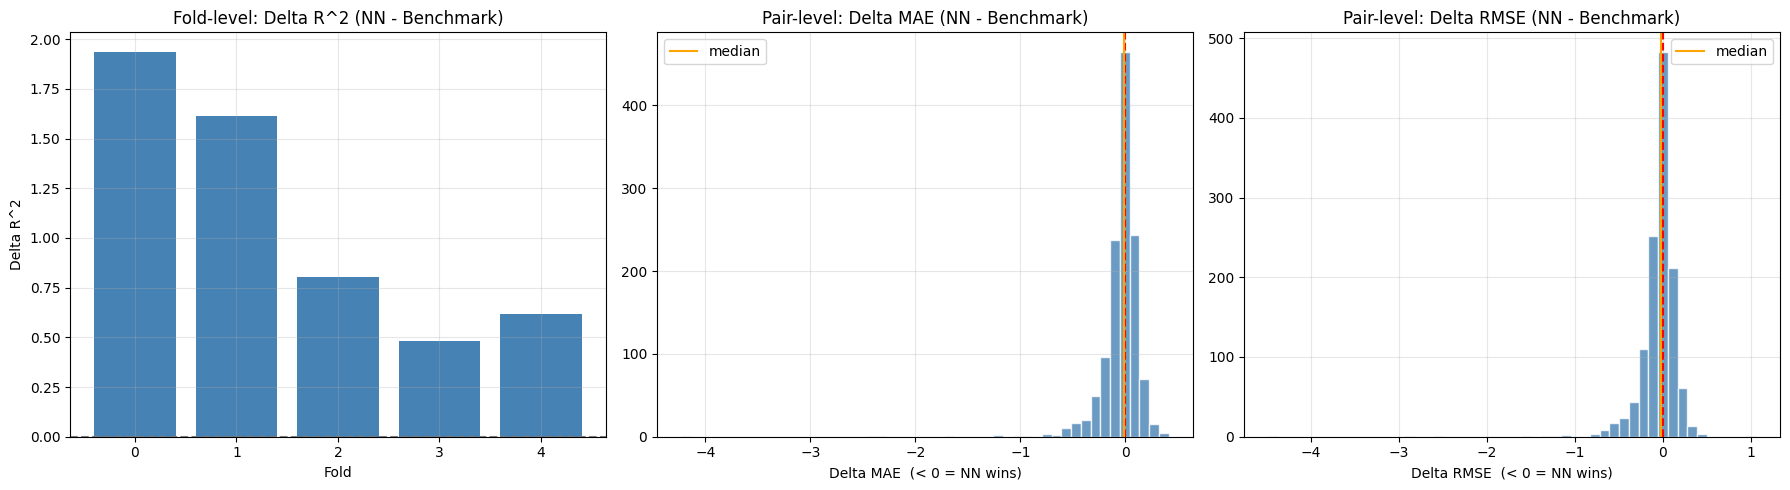

In [11]:
# ============================================================
# BLOCK 1 — Visualizations
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1a) Delta R² by fold
axes[0].bar(gen_fold["fold"].astype(str), gen_fold["delta_r2"], color="steelblue")
axes[0].axhline(0, ls="--", color="gray")
axes[0].set_title("Fold-level: Delta R^2 (NN - Benchmark)")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Delta R^2")
axes[0].grid(True, alpha=0.3)

# 1b) Histogram of pair-level delta MAE
axes[1].hist(gen_pair["delta_mae"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(0, ls="--", color="red", lw=1.5)
axes[1].axvline(gen_pair["delta_mae"].median(), ls="-", color="orange", lw=1.5, label="median")
axes[1].set_title("Pair-level: Delta MAE (NN - Benchmark)")
axes[1].set_xlabel("Delta MAE  (< 0 = NN wins)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 1b) Histogram of pair-level delta RMSE
axes[2].hist(gen_pair["delta_rmse"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[2].axvline(0, ls="--", color="red", lw=1.5)
axes[2].axvline(gen_pair["delta_rmse"].median(), ls="-", color="orange", lw=1.5, label="median")
axes[2].set_title("Pair-level: Delta RMSE (NN - Benchmark)")
axes[2].set_xlabel("Delta RMSE  (< 0 = NN wins)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Block 2: Bootstrap elasticity stability setup

In [12]:
# ============================================================
# BLOCK 2 — Better-calculated elasticity (bootstrap stability)
# ============================================================

# NN: one own-elasticity per (store, upc)
nn_own_boot = nn_boot_own.copy()
nn_own_boot["ci_width_nn"] = nn_own_boot["elasticity_ci_high"] - nn_own_boot["elasticity_ci_low"]

# Benchmark: one own-elasticity per (store, pair, upc_i, upc_j)
# A given upc_i in a store has multiple estimates (one per upc_j partner).
# Aggregate across partners to get one summary per (store, upc_i).
bench_own_agg = (
    bench_boot_sum
    .groupby(["store_code", "upc_i"], as_index=False)
    .agg(
        elast_mean_bench=("own_elasticity_mean", "mean"),
        elast_std_bench=("own_elasticity_std", "mean"),
        ci_low_bench=("own_elasticity_ci_low", "mean"),
        ci_high_bench=("own_elasticity_ci_high", "mean"),
        n_partners=("upc_j", "nunique"),
    )
)
bench_own_agg["ci_width_bench"] = bench_own_agg["ci_high_bench"] - bench_own_agg["ci_low_bench"]

# Merge
elas_cmp = nn_own_boot.merge(
    bench_own_agg,
    left_on=["store_code", "upc_code"],
    right_on=["store_code", "upc_i"],
    how="inner",
)

elas_cmp["nn_narrower_ci"]  = elas_cmp["ci_width_nn"] < elas_cmp["ci_width_bench"]
elas_cmp["nn_lower_std"]    = elas_cmp["elasticity_std"] < elas_cmp["elast_std_bench"]
elas_cmp["same_sign"]       = np.sign(elas_cmp["elasticity_mean"]) == np.sign(elas_cmp["elast_mean_bench"])
elas_cmp["nn_negative"]     = elas_cmp["elasticity_mean"] < 0
elas_cmp["bench_negative"]  = elas_cmp["elast_mean_bench"] < 0

stability = pd.DataFrame({
    "metric": [
        "n_series",
        "nn_narrower_ci_rate",
        "nn_lower_std_rate",
        "same_sign_rate",
        "nn_negative_rate (economic prior)",
        "bench_negative_rate (economic prior)",
        "median_ci_width_nn",
        "median_ci_width_bench",
        "median_std_nn",
        "median_std_bench",
    ],
    "value": [
        len(elas_cmp),
        elas_cmp["nn_narrower_ci"].mean(),
        elas_cmp["nn_lower_std"].mean(),
        elas_cmp["same_sign"].mean(),
        elas_cmp["nn_negative"].mean(),
        elas_cmp["bench_negative"].mean(),
        elas_cmp["ci_width_nn"].median(),
        elas_cmp["ci_width_bench"].median(),
        elas_cmp["elasticity_std"].median(),
        elas_cmp["elast_std_bench"].median(),
    ],
})
display(stability)

,metric,value
0,n_series,212.000000
1,nn_narrower_ci_rate,0.900943
2,nn_lower_std_rate,0.966981
3,same_sign_rate,0.985849
4,nn_negative_rate (economic prior),1.000000
5,bench_negative_rate (economic prior),0.985849
6,median_ci_width_nn,1.093293
7,median_ci_width_bench,2.693765
8,median_std_nn,0.283143
9,median_std_bench,0.791873


# Block 2: Inter-fold elasticity stability

In [13]:
# ============================================================
# BLOCK 2b — Inter-fold elasticity stability
# ============================================================

# NN: mean elasticity per (store, upc_i, fold) from k-fold predictions
nn_fold_E = (
    nn_own
    .groupby(["store_code", "upc_i", "fold"], as_index=False)
    .agg(E_mean=("E", "mean"))
)
nn_fold_std = (
    nn_fold_E
    .groupby(["store_code", "upc_i"], as_index=False)
    .agg(E_fold_std_nn=("E_mean", "std"), n_folds_nn=("E_mean", "count"))
)

# Benchmark: own_elasticity per (store, upc_i, fold), averaged over upc_j
bench_fold_E = (
    bench_gen_folds
    .groupby(["store_code", "upc_i", "fold"], as_index=False)
    .agg(own_elast_mean=("own_elasticity", "mean"))
)
bench_fold_std = (
    bench_fold_E
    .groupby(["store_code", "upc_i"], as_index=False)
    .agg(E_fold_std_bench=("own_elast_mean", "std"), n_folds_bench=("own_elast_mean", "count"))
)

# Require at least 3 folds for a meaningful std
fold_cmp = nn_fold_std.merge(bench_fold_std, on=["store_code", "upc_i"])
fold_cmp = fold_cmp[(fold_cmp["n_folds_nn"] >= 3) & (fold_cmp["n_folds_bench"] >= 3)]

fold_cmp["nn_more_stable"] = fold_cmp["E_fold_std_nn"] < fold_cmp["E_fold_std_bench"]

print(f"Series with ≥3 folds: {len(fold_cmp)}")
print(f"NN more stable across folds: {fold_cmp['nn_more_stable'].mean():.1%}")
print(f"Median fold-std NN:    {fold_cmp['E_fold_std_nn'].median():.4f}")
print(f"Median fold-std Bench: {fold_cmp['E_fold_std_bench'].median():.4f}")

Series with ≥3 folds: 272
NN more stable across folds: 60.7%
Median fold-std NN:    0.4505
Median fold-std Bench: 0.6892


# Block 2: Visualization

/tmp/ipykernel_26865/4238128035.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


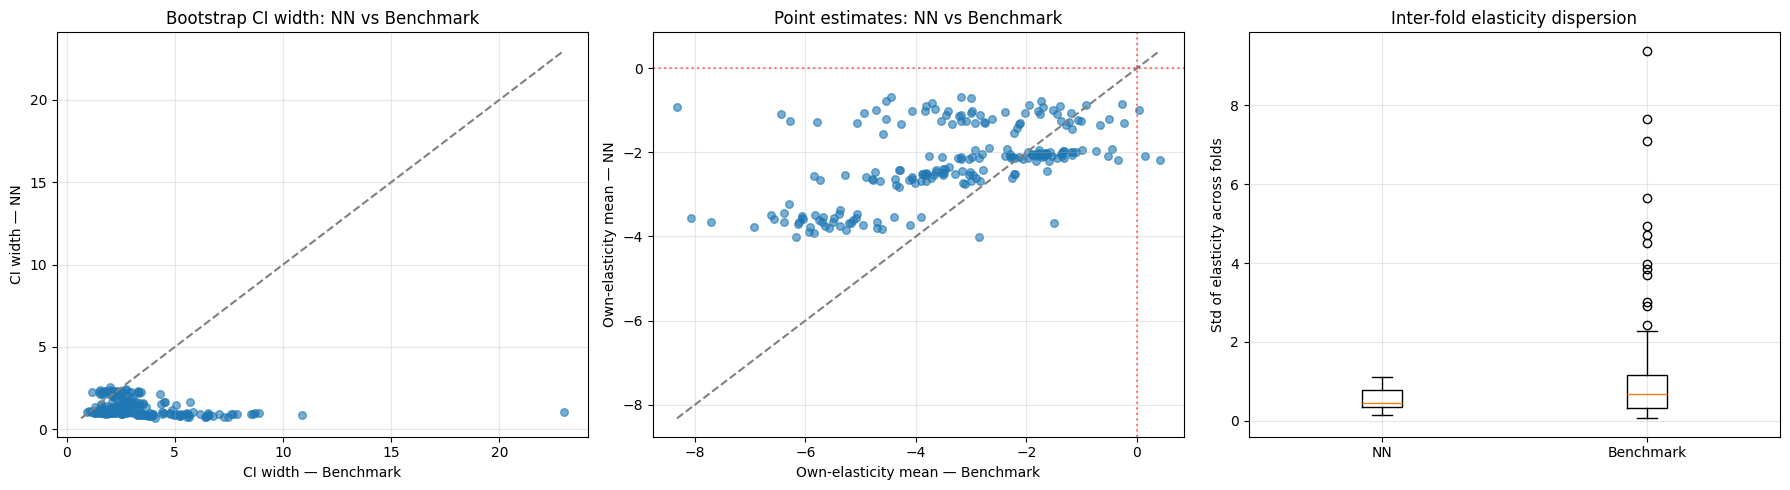

In [14]:
# ============================================================
# BLOCK 2 — Visualizations
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CI width scatter
ax = axes[0]
lo = min(elas_cmp["ci_width_bench"].min(), elas_cmp["ci_width_nn"].min())
hi = max(elas_cmp["ci_width_bench"].max(), elas_cmp["ci_width_nn"].max())
ax.scatter(elas_cmp["ci_width_bench"], elas_cmp["ci_width_nn"], alpha=0.6, s=30)
ax.plot([lo, hi], [lo, hi], ls="--", color="gray")
ax.set_xlabel("CI width — Benchmark")
ax.set_ylabel("CI width — NN")
ax.set_title("Bootstrap CI width: NN vs Benchmark")
ax.grid(True, alpha=0.3)

# Elasticity mean scatter
ax = axes[1]
lo = min(elas_cmp["elast_mean_bench"].min(), elas_cmp["elasticity_mean"].min())
hi = max(elas_cmp["elast_mean_bench"].max(), elas_cmp["elasticity_mean"].max())
ax.scatter(elas_cmp["elast_mean_bench"], elas_cmp["elasticity_mean"], alpha=0.6, s=30)
ax.plot([lo, hi], [lo, hi], ls="--", color="gray")
ax.axhline(0, ls=":", color="red", alpha=0.5)
ax.axvline(0, ls=":", color="red", alpha=0.5)
ax.set_xlabel("Own-elasticity mean — Benchmark")
ax.set_ylabel("Own-elasticity mean — NN")
ax.set_title("Point estimates: NN vs Benchmark")
ax.grid(True, alpha=0.3)

# Inter-fold std comparison
ax = axes[2]
ax.boxplot(
    [fold_cmp["E_fold_std_nn"].dropna(), fold_cmp["E_fold_std_bench"].dropna()],
    labels=["NN", "Benchmark"],
)
ax.set_ylabel("Std of elasticity across folds")
ax.set_title("Inter-fold elasticity dispersion")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Block 3: Calibration - Coverage analysis

In [15]:
# ============================================================
# BLOCK 3 — Precise elasticity (calibration analysis)
# ============================================================
# A well-calibrated 95% CI should cover ~95% of independent
# point estimates. We use k-fold point estimates as the
# independent "probe" and bootstrap CIs as the uncertainty band.

# --- NN coverage ---
nn_kfold_point = (
    nn_own
    .groupby(["store_code", "upc_i", "fold"], as_index=False)
    .agg(E_fold=("E", "mean"))
)
nn_ci = nn_boot_own[["store_code", "upc_code", "elasticity_ci_low", "elasticity_ci_high"]]

nn_calib = nn_kfold_point.merge(
    nn_ci,
    left_on=["store_code", "upc_i"],
    right_on=["store_code", "upc_code"],
)
nn_calib["covered"] = (
    (nn_calib["E_fold"] >= nn_calib["elasticity_ci_low"])
    & (nn_calib["E_fold"] <= nn_calib["elasticity_ci_high"])
)

# --- Benchmark coverage ---
bench_kfold_point = (
    bench_gen_folds
    .groupby(["store_code", "upc_i", "fold"], as_index=False)
    .agg(own_elast_fold=("own_elasticity", "mean"))
)
bench_ci = (
    bench_boot_sum
    .groupby(["store_code", "upc_i"], as_index=False)
    .agg(
        ci_low_bench=("own_elasticity_ci_low", "mean"),
        ci_high_bench=("own_elasticity_ci_high", "mean"),
    )
)
bench_calib = bench_kfold_point.merge(bench_ci, on=["store_code", "upc_i"])
bench_calib["covered"] = (
    (bench_calib["own_elast_fold"] >= bench_calib["ci_low_bench"])
    & (bench_calib["own_elast_fold"] <= bench_calib["ci_high_bench"])
)

nn_cov   = nn_calib["covered"].mean()
bench_cov = bench_calib["covered"].mean()

print(f"NN 95% CI coverage over k-fold estimates:        {nn_cov:.1%}  (n={len(nn_calib)})")
print(f"Benchmark 95% CI coverage over k-fold estimates: {bench_cov:.1%}  (n={len(bench_calib)})")
print(f"Target coverage: 95%")
print(f"NN deviation from target:    {abs(nn_cov - 0.95):.1%}  ({'under' if nn_cov < 0.95 else 'over'}confident)")
print(f"Bench deviation from target: {abs(bench_cov - 0.95):.1%}  ({'under' if bench_cov < 0.95 else 'over'}confident)")

NN 95% CI coverage over k-fold estimates:        80.7%  (n=1081)
Benchmark 95% CI coverage over k-fold estimates: 86.3%  (n=1049)
Target coverage: 95%
NN deviation from target:    14.3%  (underconfident)
Bench deviation from target: 8.7%  (underconfident)


# Block 3: Dispersion ratio

In [16]:
# ============================================================
# BLOCK 3b — Dispersion ratio: bootstrap std vs k-fold std
# ============================================================
# If the bootstrap CI is well-calibrated, the bootstrap std
# should be comparable to the inter-fold std.
# Ratio ≈ 1 → well-calibrated
# Ratio < 1 → bootstrap underestimates true variability
# Ratio > 1 → bootstrap is conservative

disp = nn_fold_std.merge(
    nn_boot_own[["store_code", "upc_code", "elasticity_std"]],
    left_on=["store_code", "upc_i"],
    right_on=["store_code", "upc_code"],
)
disp = disp[disp["E_fold_std_nn"] > 0]
disp["ratio_nn"] = disp["elasticity_std"] / disp["E_fold_std_nn"]

bench_boot_std_agg = (
    bench_boot_sum
    .groupby(["store_code", "upc_i"], as_index=False)
    .agg(elast_std_bench=("own_elasticity_std", "mean"))
)
disp_bench = bench_fold_std.merge(bench_boot_std_agg, on=["store_code", "upc_i"])
disp_bench = disp_bench[disp_bench["E_fold_std_bench"] > 0]
disp_bench["ratio_bench"] = disp_bench["elast_std_bench"] / disp_bench["E_fold_std_bench"]

print("Dispersion ratio = bootstrap_std / kfold_std  (ideal ≈ 1.0)")
print(f"  NN median ratio:        {disp['ratio_nn'].median():.2f}")
print(f"  Benchmark median ratio: {disp_bench['ratio_bench'].median():.2f}")

Dispersion ratio = bootstrap_std / kfold_std  (ideal ≈ 1.0)
  NN median ratio:        0.63
  Benchmark median ratio: 1.22


# Block 3: Visualization

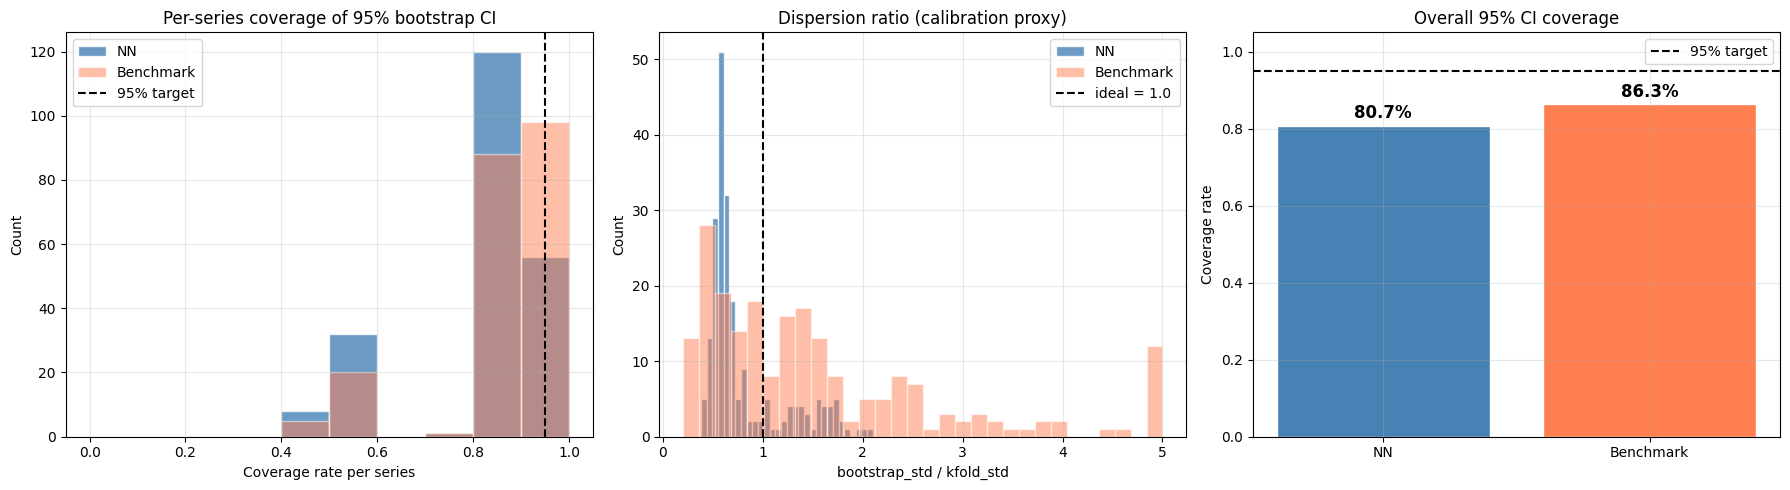

In [17]:
# ============================================================
# BLOCK 3 — Visualizations
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Coverage per series (NN)
nn_series_cov = (
    nn_calib
    .groupby(["store_code", "upc_i"], as_index=False)
    .agg(coverage=("covered", "mean"), n_folds=("covered", "count"))
)
ax = axes[0]
ax.hist(nn_series_cov["coverage"], bins=np.linspace(0, 1, 11),
        color="steelblue", edgecolor="white", alpha=0.8, label="NN")
bench_series_cov = (
    bench_calib
    .groupby(["store_code", "upc_i"], as_index=False)
    .agg(coverage=("covered", "mean"))
)
ax.hist(bench_series_cov["coverage"], bins=np.linspace(0, 1, 11),
        color="coral", edgecolor="white", alpha=0.5, label="Benchmark")
ax.axvline(0.95, ls="--", color="black", label="95% target")
ax.set_xlabel("Coverage rate per series")
ax.set_ylabel("Count")
ax.set_title("Per-series coverage of 95% bootstrap CI")
ax.legend()
ax.grid(True, alpha=0.3)

# Dispersion ratio histograms
ax = axes[1]
ax.hist(disp["ratio_nn"].clip(0, 5), bins=30,
        color="steelblue", edgecolor="white", alpha=0.8, label="NN")
ax.hist(disp_bench["ratio_bench"].clip(0, 5), bins=30,
        color="coral", edgecolor="white", alpha=0.5, label="Benchmark")
ax.axvline(1.0, ls="--", color="black", label="ideal = 1.0")
ax.set_xlabel("bootstrap_std / kfold_std")
ax.set_ylabel("Count")
ax.set_title("Dispersion ratio (calibration proxy)")
ax.legend()
ax.grid(True, alpha=0.3)

# Calibration summary bar chart
ax = axes[2]
labels = ["NN", "Benchmark"]
coverages = [nn_cov, bench_cov]
colors = ["steelblue", "coral"]
bars = ax.bar(labels, coverages, color=colors, edgecolor="white")
ax.axhline(0.95, ls="--", color="black", label="95% target")
ax.set_ylabel("Coverage rate")
ax.set_title("Overall 95% CI coverage")
ax.set_ylim(0, 1.05)
for bar, v in zip(bars, coverages):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.1%}",
            ha="center", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final Conclusion

In [18]:
# ============================================================
# FINAL CONCLUSIONS
# ============================================================

nn_wins_mae_flag  = gen_pair["delta_mae"].median() < 0
nn_wins_rmse_flag = gen_pair["delta_rmse"].median() < 0
gen_ok = nn_wins_mae_flag and nn_wins_rmse_flag

stability_ok = elas_cmp["nn_narrower_ci"].mean() > 0.5
fold_stable  = fold_cmp["nn_more_stable"].mean() > 0.5

nn_better_calib = abs(nn_cov - 0.95) < abs(bench_cov - 0.95)
nn_sharper      = elas_cmp["ci_width_nn"].median() < elas_cmp["ci_width_bench"].median()

def verdict(ok):
    return "YES" if ok else "NO / WEAK"

conclusion = pd.DataFrame({
    "Claim": [
        "1. NN generalizes better (out-of-sample prediction)",
        "2. NN elasticity is better calculated (more stable)",
        "3. NN elasticity is more precise (calibrated uncertainty)",
    ],
    "Verdict": [
        verdict(gen_ok),
        verdict(stability_ok and fold_stable),
        verdict(nn_better_calib and nn_sharper),
    ],
    "Key evidence": [
        (f"NN wins MAE in {(gen_pair['delta_mae']<0).mean():.0%} of pairs; "
         f"median ΔMAE={gen_pair['delta_mae'].median():.4f}"),

        (f"Narrower CI in {elas_cmp['nn_narrower_ci'].mean():.0%} of series; "
         f"more stable across folds in {fold_cmp['nn_more_stable'].mean():.0%}"),

        (f"Coverage NN={nn_cov:.0%} vs Bench={bench_cov:.0%} (target 95%); "
         f"CI width ratio={elas_cmp['ci_width_nn'].median()/elas_cmp['ci_width_bench'].median():.2f}"),
    ],
})

display(conclusion.style.set_properties(**{"text-align": "left"}).hide(axis="index"))

Claim,Verdict,Key evidence
1. NN generalizes better (out-of-sample prediction),YES,NN wins MAE in 58% of pairs; median ΔMAE=-0.0160
2. NN elasticity is better calculated (more stable),YES,Narrower CI in 90% of series; more stable across folds in 61%
3. NN elasticity is more precise (calibrated uncertainty),NO / WEAK,Coverage NN=81% vs Bench=86% (target 95%); CI width ratio=0.41
